# 1. Setup & Loading

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the Golden Dataset
df = pd.read_parquet("../data/final/board_golden.parquet")

# 2. Data Veracity Check

Visualize the `source_agreement` and `confidence_score` to show the "quality" of the merge

In [35]:
# Calculate counts and percentages
agreement_stats = df['source_agreement'].value_counts().reset_index()
agreement_stats.columns = ['Category', 'Count']
agreement_stats['Percentage'] = (agreement_stats['Count'] / len(df) * 100).round(2)

print("--- Source Agreement Audit ---")
print(agreement_stats)

# Calculate Weighted Confidence Score
weighted_score = (df['confidence_score'].mean()).round(2)
print(f"\nOverall Weighted Confidence Score: {weighted_score}")

--- Source Agreement Audit ---
         Category  Count  Percentage
0            both    296       55.85
1        conflict    114       21.51
2      cafef_only     97       18.30
3  vietstock_only     23        4.34

Overall Weighted Confidence Score: 0.87


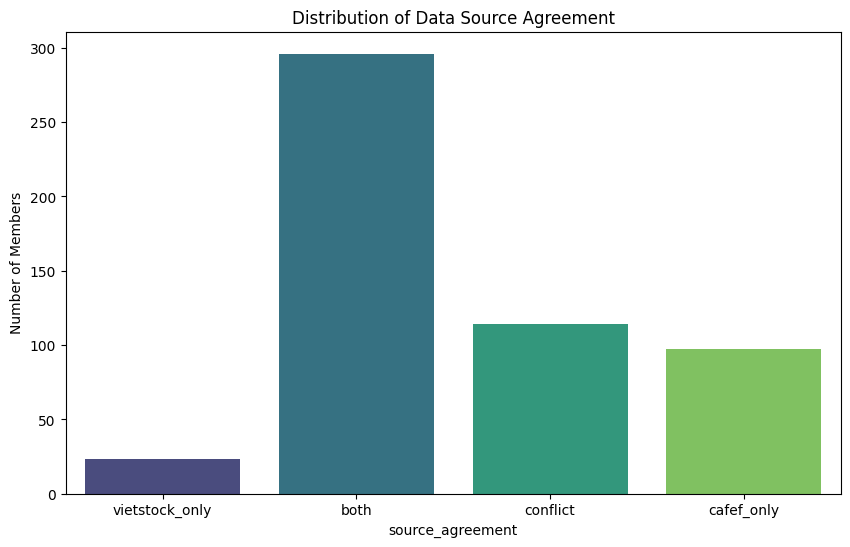

In [36]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x='source_agreement', 
    hue='source_agreement', 
    palette='viridis', 
    legend=False
)
plt.title('Distribution of Data Source Agreement')
plt.ylabel('Number of Members')
plt.show()

# 3. Board Composition Analysis

Calculate the Independence Ratio per company.

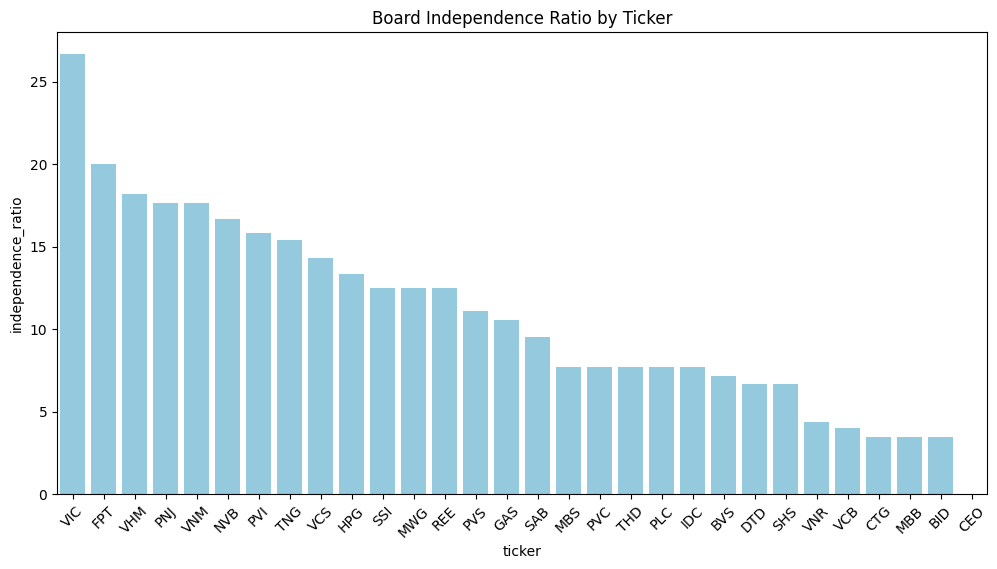

In [37]:
# Aggregate by Ticker
board_stats = df.groupby('ticker').agg(
    board_size=('person_name', 'count'),
    independents=('is_independent', 'sum')
).reset_index()

board_stats['independence_ratio'] = (board_stats['independents'] / board_stats['board_size']) * 100

# Plotting the Independence Ratio
plt.figure(figsize=(12, 6))
sns.barplot(data=board_stats.sort_values('independence_ratio', ascending=False), 
            x='ticker', y='independence_ratio', color='skyblue')

plt.title('Board Independence Ratio by Ticker')
plt.xticks(rotation=45)
plt.show()

# 4. Education Backgrounds

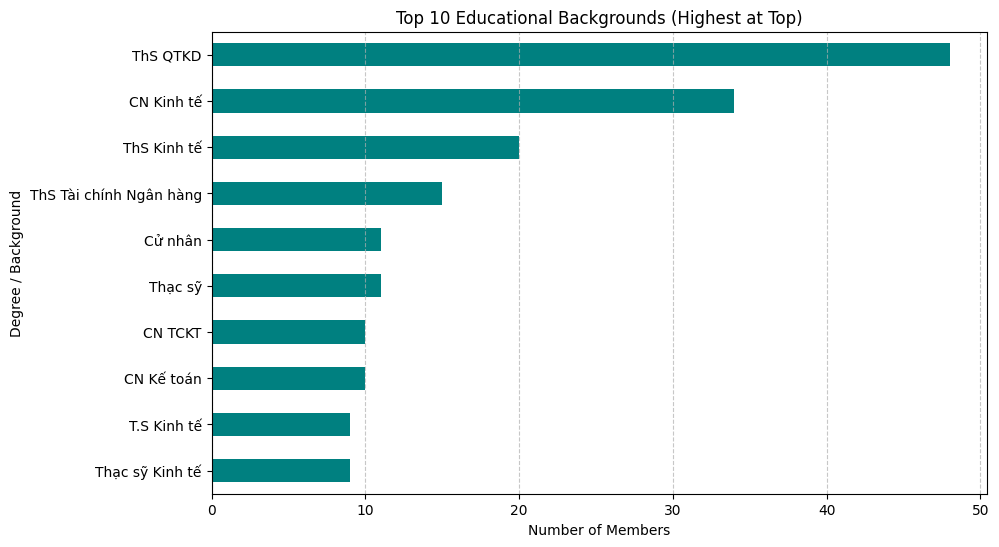

In [38]:

edu_counts = df['education'].value_counts().sort_values(ascending=False).head(10).iloc[::-1]

# Plot
plt.figure(figsize=(10, 6))
edu_counts.plot(kind='barh', color='teal')

plt.title('Top 10 Educational Backgrounds (Highest at Top)')
plt.xlabel('Number of Members')
plt.ylabel('Degree / Background')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 5. Enrichment Rate

In [39]:
# Define the fields that are unique to the Vietstock enrichment (Task 2)
enrich_fields = ['year_of_birth', 'education', 'shares', 'tenure']

# Calculate enrichment rate (records with at least one non-null enriched field)
# We check only these fields because CafeF only provides name and role
enriched_mask = df[enrich_fields].notnull().any(axis=1)
enrichment_count = enriched_mask.sum()
enrichment_rate = (enrichment_count / len(df) * 100).round(2)

print(f"--- Enrichment Performance Audit ---")
print(f"Total Golden Records: {len(df)}")
print(f"Successfully Enriched: {enrichment_count} ({enrichment_rate}%)")

# Detailed breakdown per field
field_stats = []
for field in enrich_fields:
    count = df[field].notnull().sum()
    rate = (count / len(df) * 100).round(2)
    field_stats.append({'Field': field, 'Fill_Rate (%)': rate})

df_field_stats = pd.DataFrame(field_stats)
print("\nIndividual Field Fill Rates:")
print(df_field_stats)

--- Enrichment Performance Audit ---
Total Golden Records: 530
Successfully Enriched: 430 (81.13%)

Individual Field Fill Rates:
           Field  Fill_Rate (%)
0  year_of_birth          76.60
1      education          76.79
2         shares          45.09
3         tenure          59.25
